In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
FILE_PATH = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"

f = uproot.open(FILE_PATH)

# Check what's in detsys_results
detsys_keys = [k for k in f.keys() if 'detsys' in k and 'spline' not in k]

In [8]:
POT = 7.79e20

def get_hist(key):
    h = f[key]
    values, edges = h.to_numpy()
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    errors = np.sqrt(h.variances()) if h.variances() is not None else np.sqrt(values)
    # Convert from candidates/1e18 POT to actual event counts
    scale = POT / 1e18
    return centers, widths, values * scale, errors * scale

centers, widths, nom_vals, nom_errs = get_hist("detsys_results/cv")

print(f"Number of bins: {len(centers)}")
print(f"Bin edges (first/last): {centers[0]:.1f} → {centers[-1]:.1f}")
print(f"Total nominal events: {nom_vals.sum():.1f}")
print(f"Bin centers: {centers}")

Number of bins: 11
Bin edges (first/last): 50.0 → 4500.0
Total nominal events: 102089.0
Bin centers: [  50.  150.  300.  500.  700.  900. 1250. 1750. 2500. 3500. 4500.]


In [9]:
STYLE_PATH = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/gundam-icarus/style.mplstyle"
plt.style.use(STYLE_PATH)

VAR_INFO = {
    "var01": {"label": "Induction Gain",         "sigma": "1σ",   "one_sided": False},
    "var02": {"label": "TPC Coherent Noise",      "sigma": "4.9%", "one_sided": False},
    "var03": {"label": "TPC Intrinsic Noise",     "sigma": "10%",  "one_sided": False},
    "var04": {"label": "Lifetime",                "sigma": "1σ",   "one_sided": False},
    "var05": {"label": "Scintillation (PMT QE)",  "sigma": "1σ",   "one_sided": True},
    "var06": {"label": "Induction Gap",           "sigma": "1σ",   "one_sided": True},
    "var07": {"label": "YZ Uniformity",           "sigma": "1σ",   "one_sided": True},
    "var08": {"label": "Recombination",           "sigma": "1σ",   "one_sided": True},
}

X_LABEL = r'$\mathbf{Reco\ Leading\ Muon\ KE\ [MeV]}$'
Y_LABEL_TOP = r'$\mathbf{Events\ /\ bin}$'
Y_LABEL_BOT = r'$\mathbf{Var\ /\ CV}$'

In [10]:
def add_icarus_labels(ax):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey       = yrange[1] + 0.01 * (yrange[1] - yrange[0])
    usex       = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    usex_right = xrange[1] - 0.025 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\n' + 'Work-in-Progress',
            fontsize=10, color="blue",
            verticalalignment="bottom", fontfamily="sans-serif")

def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=12, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', size=4, width=1, direction='in')
    ax.tick_params(axis='x', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')


def fill_panels(fig, gs, col, var_vals, var_errs, var_label):
    ax_top = fig.add_subplot(gs[0, col])
    ax_bot = fig.add_subplot(gs[1, col], sharex=ax_top)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # ── Top panel ──────────────────────────────────────────────────────
    ax_top.errorbar(centers, nom_vals, yerr=nom_errs, xerr=widths/2,
                    fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black",
                    color="black", capsize=4, capthick=1.5, elinewidth=1.75,
                    linewidth=2, label="CV")
    ax_top.errorbar(centers, var_vals, yerr=var_errs, xerr=widths/2,
                    fmt='o', markersize=4,
                    markerfacecolor="red", markeredgecolor="red",
                    color="red", capsize=4, capthick=1.5, elinewidth=1.75,
                    linewidth=2, label=var_label)

    ax_top.set_ylabel(r'$\mathbf{Events}$', fontsize=12)
    ax_top.legend(fontsize=10)
    ax_top.set_xlim(centers[0] - 50, centers[-1] + 50)
    y_max = np.max(np.concatenate([nom_vals + nom_errs, var_vals + var_errs])) * 1.2
    ax_top.set_ylim(0, y_max)
    ax_top.grid(True, alpha=0.3)
    apply_tick_style(ax_top)
    add_icarus_labels(ax_top)

    # ── Ratio panel ────────────────────────────────────────────────────
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio     = np.where(nom_vals > 0, var_vals / nom_vals, np.nan)
        rel_var   = np.where(var_vals > 0, (var_errs / var_vals)**2, 0)
        rel_nom   = np.where(nom_vals > 0, (nom_errs / nom_vals)**2, 0)
        ratio_err = np.abs(ratio) * np.sqrt(rel_var + rel_nom)

    ax_bot.axhline(y=1, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
    ax_bot.errorbar(centers, ratio, yerr=ratio_err, xerr=widths/2,
                    fmt='o', markersize=4,
                    markerfacecolor='darkblue', markeredgecolor='darkblue',
                    color='darkblue', capsize=4, capthick=1.5, elinewidth=1.75,
                    linewidth=2)
    ax_bot.set_ylabel(r'$\mathbf{Var\ /\ CV}$', fontsize=12)
    ax_bot.set_xlabel(r'$\mathbf{Reco\ Leading\ Muon\ KE\ [MeV]}$', fontsize=12)
    ax_bot.set_ylim(0, 2.0)
    ax_bot.grid(True, alpha=0.3)
    apply_tick_style(ax_bot)

    return ax_top, ax_bot


def plot_variation(var_key, info):
    one_sided = info["one_sided"]
    label     = info["label"]
    sigma     = info["sigma"]
    ncols     = 1 if one_sided else 2

    fig = plt.figure(figsize=(6 * ncols, 6))
    fig.set_constrained_layout(False)
    gs = gridspec.GridSpec(2, ncols, figure=fig,
                           height_ratios=[3, 1], hspace=0.05, wspace=0.35)

    if one_sided:
        c, w, v, e = get_hist(f"detsys_results/{var_key}")
        fill_panels(fig, gs, 0, v, e, f"{label} ({sigma})")
    else:
        cp, wp, vp, ep = get_hist(f"detsys_results/{var_key}p")
        cm, wm, vm, em = get_hist(f"detsys_results/{var_key}m")
        fill_panels(fig, gs, 0, vp, ep, f"{label} (+{sigma})")
        fill_panels(fig, gs, 1, vm, em, f"{label} (-{sigma})")

    SAVE_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/DetSys_Plots"
    import os
    os.makedirs(SAVE_DIR, exist_ok=True)
    fig.savefig(os.path.join(SAVE_DIR, f"{var_key}_vs_CV.png"), dpi=300, bbox_inches='tight')
    plt.show()

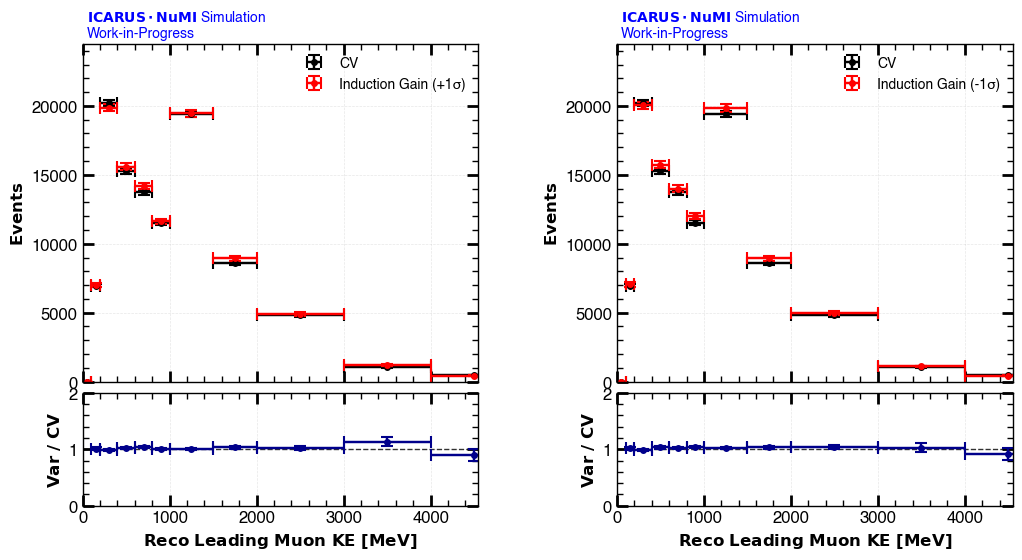

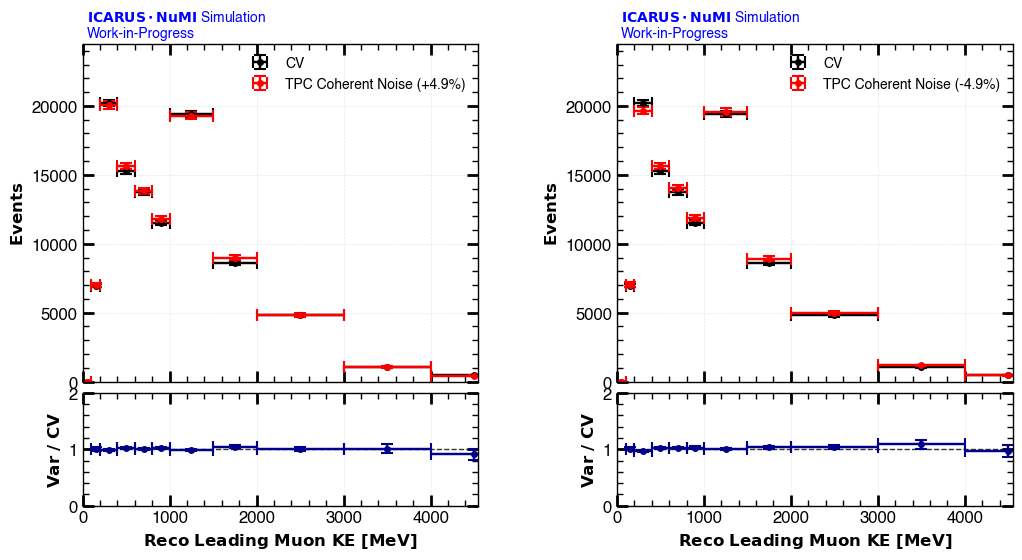

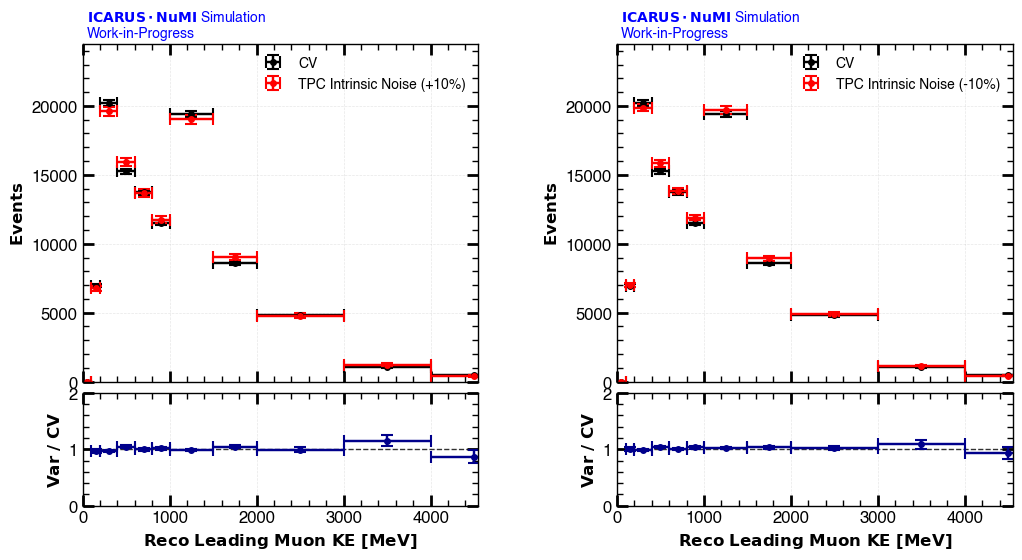

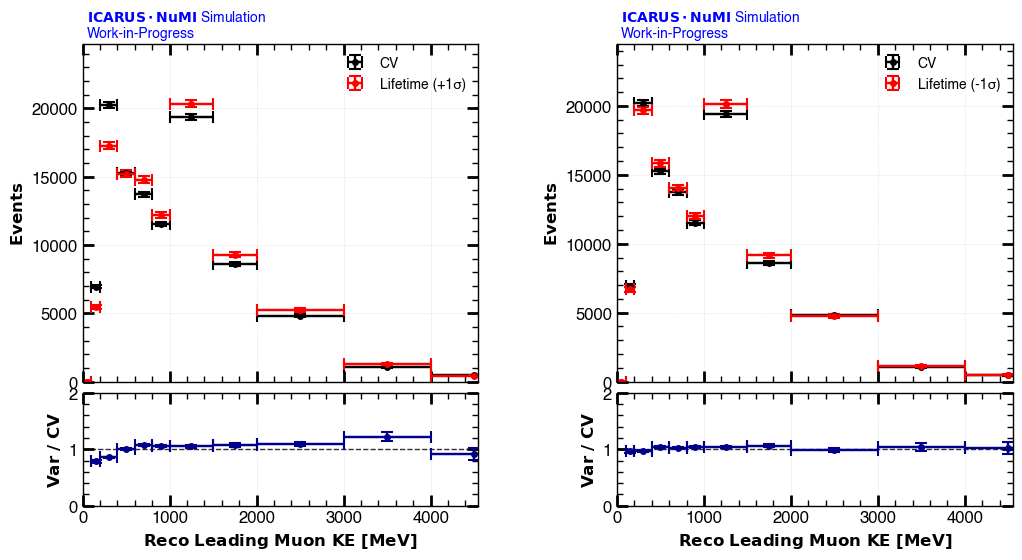

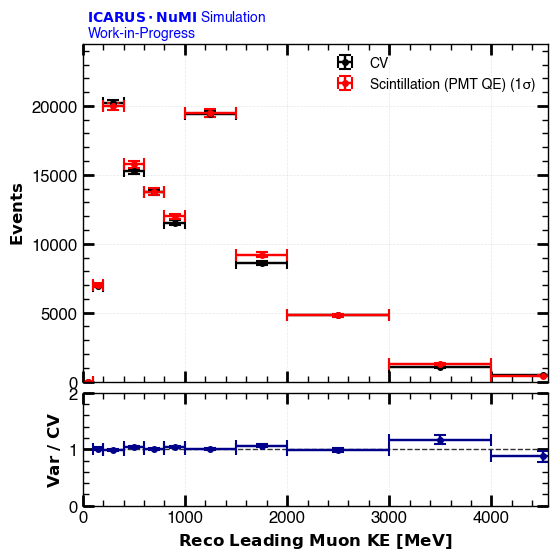

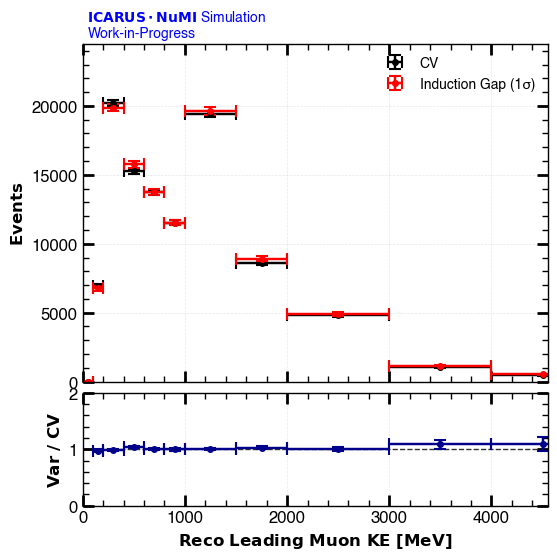

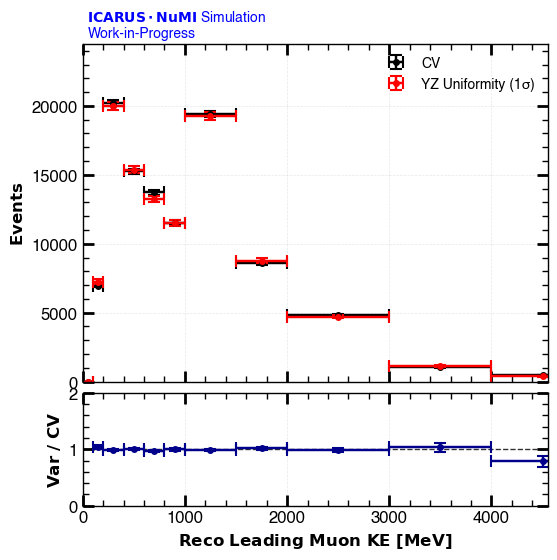

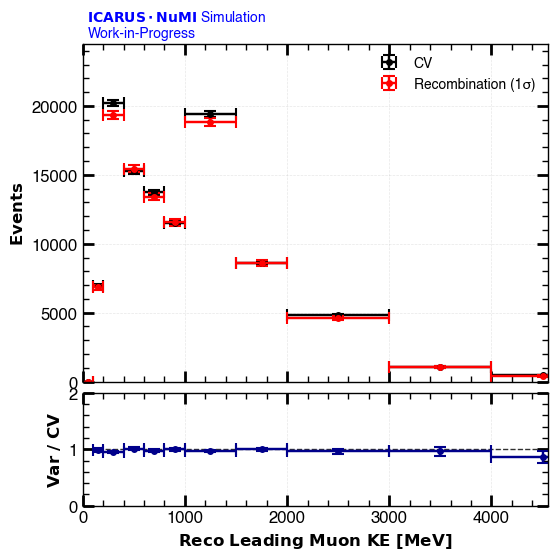

In [11]:
for var_key, info in VAR_INFO.items():
    plot_variation(var_key, info)